# Step 1 - Imports

In [ ]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, MultiHeadAttention,
    Conv1D, GlobalAveragePooling1D, Add
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Step 2 — Reproducibility

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Step 3— Mount drive and load files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Speech_emotion_recognition/RAVDESS"
files = glob.glob(os.path.join(DATA_PATH, "Actor_*", "*.wav"))

print("Total files found:", len(files))
print("Sample file:", files[0])

Mounted at /content/drive
Total files found: 1440
Sample file: /content/drive/MyDrive/Speech_emotion_recognition/RAVDESS/Actor_24/03-01-01-01-02-02-24.wav


#Step 4 — Emotion dictionary

In [ ]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

#Step 5 — Build dataframe

In [ ]:
data = []

for file in files:
    filename = os.path.basename(file)
    parts = filename.replace(".wav", "").split("-")

    modality = parts[0]
    vocal_channel = parts[1]
    emotion_code = parts[2]
    intensity = parts[3]
    statement = parts[4]
    repetition = parts[5]
    actor = parts[6]

    data.append({
        "path": file,
        "filename": filename,
        "modality": modality,
        "vocal_channel": vocal_channel,
        "emotion_code": emotion_code,
        "emotion": emotion_dict[emotion_code],
        "intensity": intensity,
        "statement": statement,
        "repetition": repetition,
        "actor": int(actor)
    })

df = pd.DataFrame(data)
print(df.shape)
df.head()
print()
print("\nEmotion counts:")
print(df["emotion"].value_counts())

(1440, 10)


Emotion counts:
emotion
calm         192
happy        192
sad          192
angry        192
disgust      192
fearful      192
surprised    192
neutral       96
Name: count, dtype: int64


# Step 6— Violin plot

Calculating durations...


  0%|          | 0/1440 [00:00<?, ?it/s]

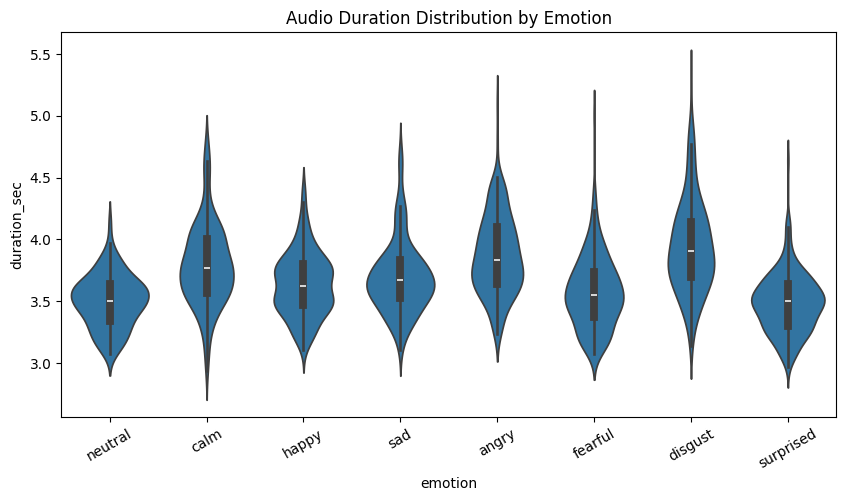

In [ ]:
from tqdm.notebook import tqdm
tqdm.pandas()

def get_duration_fast(file_path):
    # uses metadata instead
    return librosa.get_duration(path=file_path)

print("Calculating durations...")

# progress indicator
df["duration_sec"] = df["path"].progress_apply(get_duration_fast)

plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x="emotion", y="duration_sec")
plt.title("Audio Duration Distribution by Emotion")
plt.xticks(rotation=30)
plt.show()

#Step 7 — one mel spectrogram sample

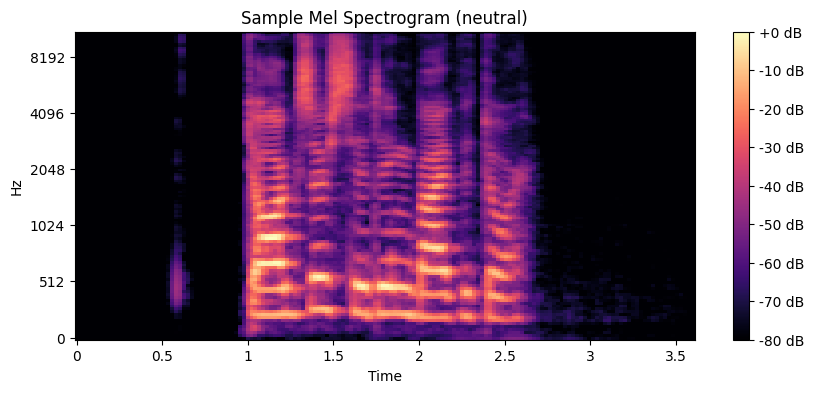

In [ ]:
sample_path = df.loc[0, "path"]
sample_emotion = df.loc[0, "emotion"]

signal, sr = librosa.load(sample_path, sr=22050)
mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Sample Mel Spectrogram ({sample_emotion})")
plt.show()

# Step 8 — Feature extraction for Conformer

In [ ]:
def extract_mel_conformer(file_path, sr=22050, n_mels=128, max_len=128):
    signal, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # fix width to max_len
    if mel_db.shape[1] > max_len:
        mel_db = mel_db[:, :max_len]
    else:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')

    # normalize
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-8)

    # transpose to (time_steps, n_mels)
    mel_db = mel_db.T

    return mel_db

# Step 9 — Build X and y

In [ ]:
X = []
y = []

for i, row in df.iterrows():
    if i % 100 == 0:
        print(f"Processing {i}/{len(df)}")

    feature = extract_mel_conformer(row["path"])
    X.append(feature)
    y.append(row["emotion"])

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)   # expected: (samples, 128, 128)
print("y shape:", y.shape)

Processing 0/1440
Processing 100/1440
Processing 200/1440
Processing 300/1440
Processing 400/1440
Processing 500/1440
Processing 600/1440
Processing 700/1440
Processing 800/1440
Processing 900/1440
Processing 1000/1440
Processing 1100/1440
Processing 1200/1440
Processing 1300/1440
Processing 1400/1440
X shape: (1440, 128, 128)
y shape: (1440,)


# step 10 — Visualize one processed input

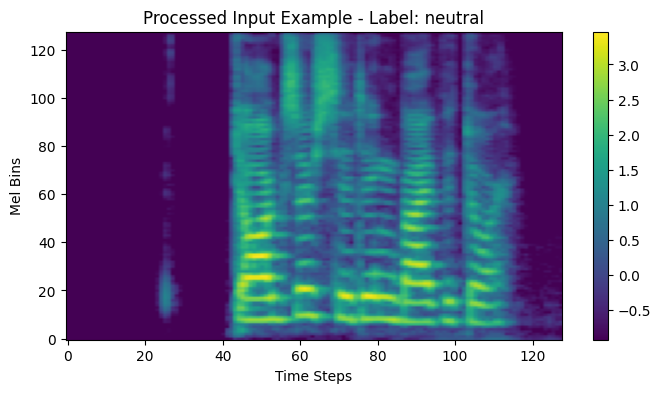

In [ ]:
plt.figure(figsize=(8, 4))
plt.imshow(X[0].T, aspect='auto', origin='lower')
plt.colorbar()
plt.title(f"Processed Input Example - Label: {y[0]}")
plt.xlabel("Time Steps")
plt.ylabel("Mel Bins")
plt.show()

 # step 11 — Label encoding

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)
print("y_categorical shape:", y_categorical.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y_categorical shape: (1440, 8)


# Step 12 — Train/test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1152, 128, 128)
X_test : (288, 128, 128)
y_train: (1152, 8)
y_test : (288, 8)


# step 13 PCA plot on raw features

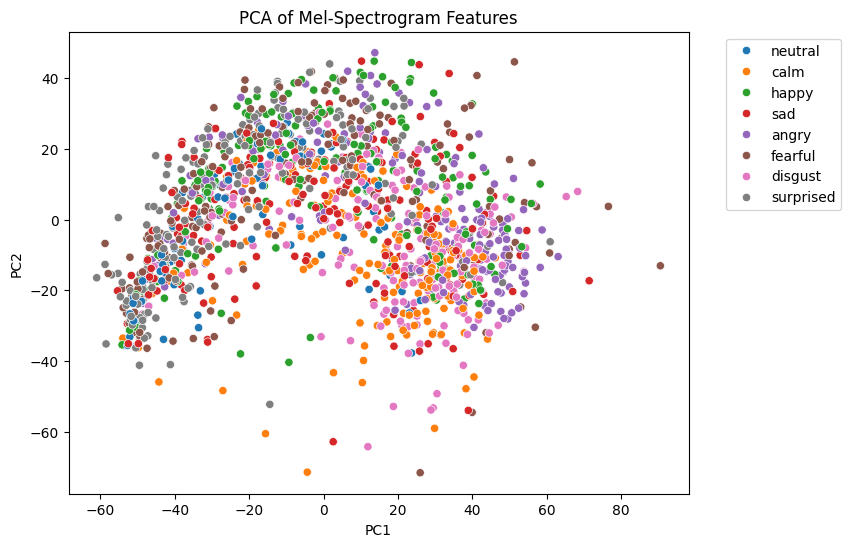

In [ ]:
X_flat = X.reshape(X.shape[0], -1)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_flat)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "emotion": y
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="emotion", palette="tab10")
plt.title("PCA of Mel-Spectrogram Features")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# step 14 — Conformer block

In [ ]:
def conformer_block(x, head_size=64, num_heads=4, ff_dim=128, conv_dim=128, dropout=0.2):
    # 1) Feed Forward
    ff1 = LayerNormalization()(x)
    ff1 = Dense(ff_dim, activation='swish')(ff1)
    ff1 = Dropout(dropout)(ff1)
    ff1 = Dense(x.shape[-1])(ff1)
    x = Add()([x, ff1])

    # 2) Multi-Head Self Attention
    attn = LayerNormalization()(x)
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(attn, attn)
    x = Add()([x, attn])

    # 3) Convolution module
    conv = LayerNormalization()(x)
    conv = Conv1D(filters=conv_dim, kernel_size=3, padding="same", activation="swish")(conv)
    conv = Dropout(dropout)(conv)
    conv = Conv1D(filters=x.shape[-1], kernel_size=1, padding="same")(conv)
    x = Add()([x, conv])

    # 4) Feed Forward again
    ff2 = LayerNormalization()(x)
    ff2 = Dense(ff_dim, activation='swish')(ff2)
    ff2 = Dropout(dropout)(ff2)
    ff2 = Dense(x.shape[-1])(ff2)
    x = Add()([x, ff2])

    return LayerNormalization()(x)

# Step 15 — Build Conformer model

In [ ]:
def build_conformer_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # projection layer
    x = Dense(128)(inputs)

    # 2 lightweight conformer blocks
    x = conformer_block(x, head_size=32, num_heads=4, ff_dim=128, conv_dim=128, dropout=0.2)
    x = conformer_block(x, head_size=32, num_heads=4, ff_dim=128, conv_dim=128, dropout=0.2)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

model = build_conformer_model(
    input_shape=X_train.shape[1:],
    num_classes=y_train.shape[1]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 128)  │     16,512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 128)  │        256 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 128)  │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128)  │          0 │ dense[0][0],      │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 128)  │     49,280 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128)  │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     16,512 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 128)  │          0 │ add_1[0][0],      │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 128)  │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128, 128)  │     16,512 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 128)  │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_4[0][0]   

 Total params: 423,624 (1.62 MB)

 Trainable params: 423,624 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

# step 16 — Compile model

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# step 17 — Early stop

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

# step 18 — Train model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 44s 417ms/step - accuracy: 0.1727 - loss: 2.0991 - val_accuracy: 0.2535 - val_loss: 1.9307 - learning_rate: 0.0010
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 38s 387ms/step - accuracy: 0.2318 - loss: 1.9392 - val_accuracy: 0.2882 - val_loss: 1.8267 - learning_rate: 0.0010
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 401ms/step - accuracy: 0.2995 - loss: 1.8040 - val_accuracy: 0.3646 - val_loss: 1.6755 - learning_rate: 0.0010
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 387ms/step - accuracy: 0.3316 - loss: 1.7395 - val_accuracy: 0.2812 - val_loss: 1.7953 - learning_rate: 0.0010
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 399ms/step - accuracy: 0.3377 - loss: 1.6829 - val_accuracy: 0.4028 - val_loss: 1.4908 - learning_rate: 0.0010
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 388ms/step - accuracy: 0.3837 - loss: 1.5980 - val_accuracy: 0.3993 - val_loss: 1.4623 - learning_rate: 0.0010
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 384ms/step - accuracy: 0.4236 - loss: 1.

#Step 19 — Plot accuracy

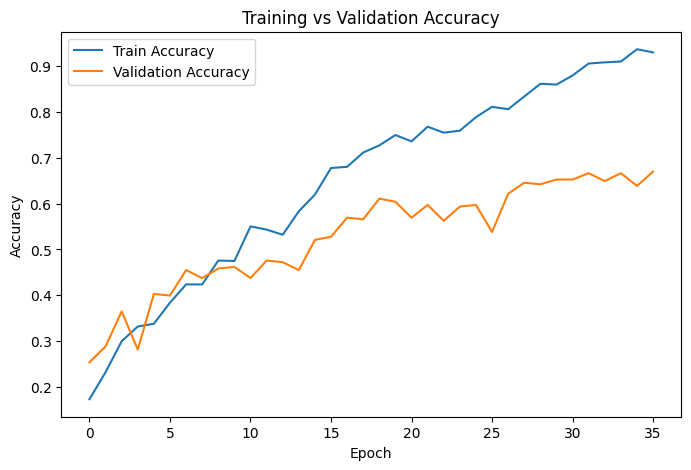

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Step 20 — Evaluate

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", acc)
print("Test Loss:", loss)

Test Accuracy: 0.6458333134651184
Test Loss: 1.0916452407836914


#Step 21— Confusion matrix

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step


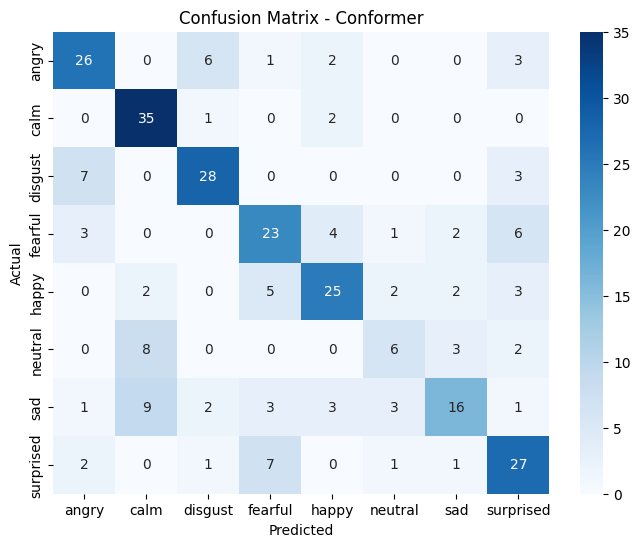

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Conformer")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# step 22 — Classification report

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.67      0.68      0.68        38
        calm       0.65      0.92      0.76        38
     disgust       0.74      0.74      0.74        38
     fearful       0.59      0.59      0.59        39
       happy       0.69      0.64      0.67        39
     neutral       0.46      0.32      0.38        19
         sad       0.67      0.42      0.52        38
   surprised       0.60      0.69      0.64        39

    accuracy                           0.65       288
   macro avg       0.63      0.63      0.62       288
weighted avg       0.64      0.65      0.64       288



# step 23 — Extract embeddings for t-SNE

In [ ]:
embedding_model = Model(
 inputs=model.input,
 outputs=model.layers[-3].output # Dense(64, relu) layer
)

X_embed_all = embedding_model.predict(X)
print("Embedding shape:", X_embed_all.shape) # Should be (1440, 64)

45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step
Embedding shape: (1440, 64)


 # step 24 — t-SNE plot on learned embeddings

Saved 1440 rows to /content/drive/MyDrive/Speech_emotion_recognition/data/tsne_data.csv

First 5 rows:


,x,y,emotion
0,21.198977,-10.579083,neutral
1,26.795446,-12.487813,neutral
2,20.922941,-10.683135,neutral
3,26.849695,-4.749241,calm
4,38.509415,-10.260725,calm


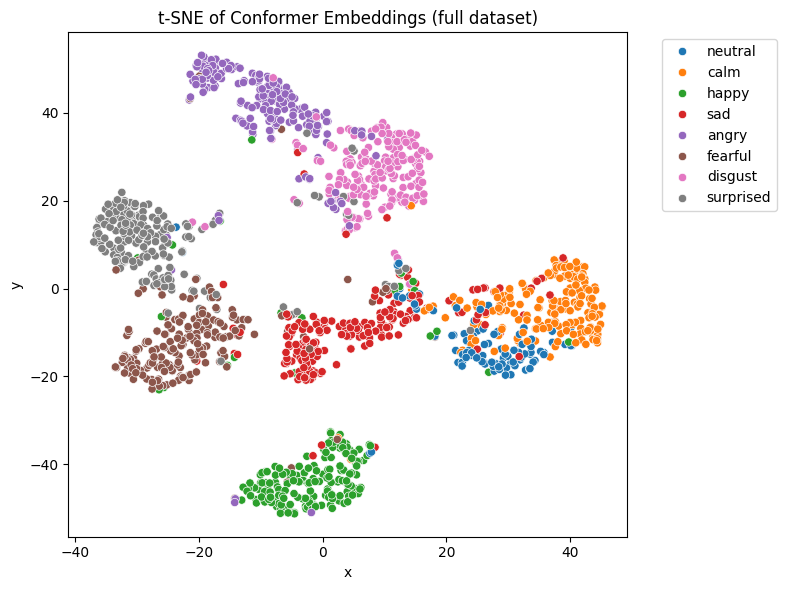

In [29]:
# Run t-SNE on all 1,440 embeddings
tsne = TSNE(
  n_components=2,
  perplexity=30,
  learning_rate='auto',
  init='pca',
  random_state=SEED
)

X_tsne = tsne.fit_transform(X_embed_all)

# Use ALL labels (y_encoded contains integer indices for the full X array)
all_emotions = label_encoder.inverse_transform(y_encoded)

# Build dataframe with the column names the Streamlit app expects
tsne_df = pd.DataFrame({
  "x": X_tsne[:, 0],
  "y": X_tsne[:, 1],
  "emotion": all_emotions
})

# Save to Drive
SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/data/"
os.makedirs(SAVE_PATH, exist_ok=True)
tsne_df.to_csv(os.path.join(SAVE_PATH, "tsne_data.csv"), index=False)

print(f"Saved {len(tsne_df)} rows to {SAVE_PATH}tsne_data.csv")
print("\nFirst 5 rows:")
display(tsne_df.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="x", y="y", hue="emotion", palette="tab10")
plt.title("t-SNE of Conformer Embeddings (full dataset)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 25 — Exporting the Model

In [ ]:
import joblib
import os

SAVE_PATH = "/content/drive/MyDrive/Speech_emotion_recognition/models/"
os.makedirs(SAVE_PATH, exist_ok=True)

# Save the Keras model in .h5 format
model.save(SAVE_PATH + "conformer_model.h5")

# Save the label encoder
joblib.dump(label_encoder, SAVE_PATH + "label_encoder.pkl")
print("Saved to:", SAVE_PATH)
